## Install and Import Required Libraries

In [1]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer, PorterStemmer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# Download NLTK resources
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

print("All libraries imported successfully!")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\acer\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\acer\AppData\Roaming\nltk_data...
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\acer\AppData\Roaming\nltk_data...


All libraries imported successfully!


## Helper Function for Text Cleaning:

Implement a Helper Function as per Text Preprocessing Notebook and Complete the following pipeline.

# Build a Text Cleaning Pipeline

In [2]:
def text_cleaning_pipeline(dataset, rule="lemmatize"):
    """
    This function takes a raw text string and applies a full cleaning pipeline:
    - Lowercasing
    - Removing URLs
    - Removing emojis
    - Removing mentions, punctuation, and special characters
    - Tokenization
    - Stopword removal
    - Lemmatization or Stemming
    """
    # Convert the input to small/lower order.
    data = dataset.lower()

    # Remove URLs
    data = re.sub(r'http\S+|www\S+|https\S+', '', data, flags=re.MULTILINE)

    # Remove emojis
    emoji_pattern = re.compile(
        "["
        u"\U0001F600-\U0001F64F"  # emoticons
        u"\U0001F300-\U0001F5FF"  # symbols & pictographs
        u"\U0001F680-\U0001F6FF"  # transport & map symbols
        u"\U0001F1E0-\U0001F1FF"  # flags
        u"\U00002702-\U000027B0"
        u"\U000024C2-\U0001F251"
        "]+", flags=re.UNICODE
    )
    data = emoji_pattern.sub(r'', data)

    # Remove all other unwanted characters (mentions, hashtags symbols, punctuation, numbers, special chars)
    data = re.sub(r'@\w+', '', data)        # remove mentions
    data = re.sub(r'#', '', data)            # remove hashtag symbol (keep the word)
    data = re.sub(r'[^a-zA-Z\s]', '', data) # keep only letters and spaces

    # Create tokens.
    tokens = data.split()

    # Remove stopwords:
    stop_words = set(stopwords.words('english'))
    tokens = [word for word in tokens if word not in stop_words]

    if rule == "lemmatize":
        lemmatizer = WordNetLemmatizer()
        tokens = [lemmatizer.lemmatize(word) for word in tokens]
    elif rule == "stem":
        stemmer = PorterStemmer()
        tokens = [stemmer.stem(word) for word in tokens]
    else:
        print("Pick between lemmatize or stem")

    return " ".join(tokens)

In [3]:
# Quick test of the pipeline
sample = "RT @JohnLeguizamo: #trump not draining swamp https://t.co/gFBvUkMX9z 😂😂"
print("Original:", sample)
print("Cleaned :", text_cleaning_pipeline(sample))

Original: RT @JohnLeguizamo: #trump not draining swamp https://t.co/gFBvUkMX9z 😂😂
Cleaned : rt trump draining swamp


# Text Classification using Machine Learning Models

### 📝 Instructions: Trump Tweet Sentiment Classification

1. **Load the Dataset**  
2. **Text Cleaning and Tokenization**  
3. **Train-Test Split**  
4. **TF-IDF Vectorization**  
5. **Model Training and Evaluation**

## Step 1: Load the Dataset

In [4]:
# Load the dataset
df = pd.read_csv('trum_tweet_sentiment_analysis.csv')

print("Dataset shape:", df.shape)
print("\nColumn names:", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Dataset shape: (1850123, 2)

Column names: ['text', 'Sentiment']

First 5 rows:


,text,Sentiment
0,RT @JohnLeguizamo: #trump not draining swamp b...,0
1,ICYMI: Hackers Rig FM Radio Stations To Play A...,0
2,Trump protests: LGBTQ rally in New York https:...,1
3,"""Hi I'm Piers Morgan. David Beckham is awful b...",0
4,RT @GlennFranco68: Tech Firm Suing BuzzFeed fo...,0


In [5]:
# Check for missing values and label distribution
print("Missing values:")
print(df.isnull().sum())
print("\nSentiment label distribution:")
print(df['Sentiment'].value_counts())

Missing values:
text         0
Sentiment    0
dtype: int64

Sentiment label distribution:
Sentiment
0    1244211
1     605912
Name: count, dtype: int64


In [6]:
# Drop rows with missing text
df = df.dropna(subset=['text'])

# The dataset is very large (~2.4M rows). We sample a subset for faster processing.
# You can increase this number if you have more time/compute.
df_sample = df.sample(n=50000, random_state=42).reset_index(drop=True)
print("Sampled dataset shape:", df_sample.shape)
print("\nSentiment distribution in sample:")
print(df_sample['Sentiment'].value_counts())

Sampled dataset shape: (50000, 2)

Sentiment distribution in sample:
Sentiment
0    33620
1    16380
Name: count, dtype: int64


## Step 2: Text Cleaning and Tokenization

In [7]:
# Apply the text cleaning pipeline to the 'text' column
df_sample['cleaned_text'] = df_sample['text'].astype(str).apply(lambda x: text_cleaning_pipeline(x, rule="lemmatize"))

print("Cleaning complete!")
print("\nSample comparison:")
for i in range(3):
    print(f"\n--- Row {i} ---")
    print("Original:", df_sample['text'].iloc[i])
    print("Cleaned :", df_sample['cleaned_text'].iloc[i])

Cleaning complete!

Sample comparison:

--- Row 0 ---
Original: RT @EthandeMarsi: I don't understand why adults would be mean to a kid! We're the same age! @realDonaldTrump , I'll be friends w/Barr https://t.co/1zFUGhrU0s
Cleaned : rt dont understand adult would mean kid age ill friend wbarr

--- Row 1 ---
Original: RT @atrumptastrophe: Suddenly that 3AM call between Trump and Flynn last week about "the value of the dollar" looks quite suspicious.
Cleaned : rt suddenly call trump flynn last week value dollar look quite suspicious

--- Row 2 ---
Original: @RealJeremyNolt~'going after Trump loyalists'for very good reasons.Trump family is breaking its commitment to limit its business interests??
Cleaned : going trump loyalistsfor good reasonstrump family breaking commitment limit business interest


In [8]:
# Remove any rows where cleaned text is empty after preprocessing
df_sample = df_sample[df_sample['cleaned_text'].str.strip() != '']
print("Dataset shape after removing empty texts:", df_sample.shape)

Dataset shape after removing empty texts: (49999, 3)


## Step 3: Train-Test Split

In [9]:
# Define features (X) and labels (y)
X = df_sample['cleaned_text']
y = df_sample['Sentiment']

# Split into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Training set size:", X_train.shape[0])
print("Testing set size :", X_test.shape[0])
print("\nTraining label distribution:")
print(y_train.value_counts())
print("\nTesting label distribution:")
print(y_test.value_counts())

Training set size: 39999
Testing set size : 10000

Training label distribution:
Sentiment
0    26895
1    13104
Name: count, dtype: int64

Testing label distribution:
Sentiment
0    6724
1    3276
Name: count, dtype: int64


## Step 4: TF-IDF Vectorization

In [10]:
# Initialize TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=10000)

# Fit on training data and transform both train and test
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print("TF-IDF Training matrix shape:", X_train_tfidf.shape)
print("TF-IDF Testing matrix shape :", X_test_tfidf.shape)

TF-IDF Training matrix shape: (39999, 10000)
TF-IDF Testing matrix shape : (10000, 10000)


## Step 5: Model Training and Evaluation (Logistic Regression)

In [11]:
# Initialize and train Logistic Regression model
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_tfidf, y_train)

print("Model training complete!")

Model training complete!


In [12]:
# Make predictions on the test set
y_pred = model.predict(X_test_tfidf)

# Print the classification report
print("Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=['Negative (0)', 'Positive (1)']))

Classification Report:

              precision    recall  f1-score   support

Negative (0)       0.88      0.96      0.92      6724
Positive (1)       0.89      0.74      0.81      3276

    accuracy                           0.88     10000
   macro avg       0.89      0.85      0.86     10000
weighted avg       0.88      0.88      0.88     10000



In [13]:
# Print overall accuracy
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print(f"Overall Accuracy: {accuracy:.4f}")

Overall Accuracy: 0.8845


## Step 6: Training vs Testing Accuracy

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Training accuracy
y_train_pred = model.predict(X_train_tfidf)
train_accuracy = accuracy_score(y_train, y_train_pred)

# Testing accuracy (already computed)
test_accuracy = accuracy_score(y_test, y_pred)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Testing Accuracy : {test_accuracy:.4f}")
print(f"Difference       : {train_accuracy - test_accuracy:.4f}")

Training Accuracy: 0.9098
Testing Accuracy : 0.8845
Difference       : 0.0253


## Step 7: Visualizations

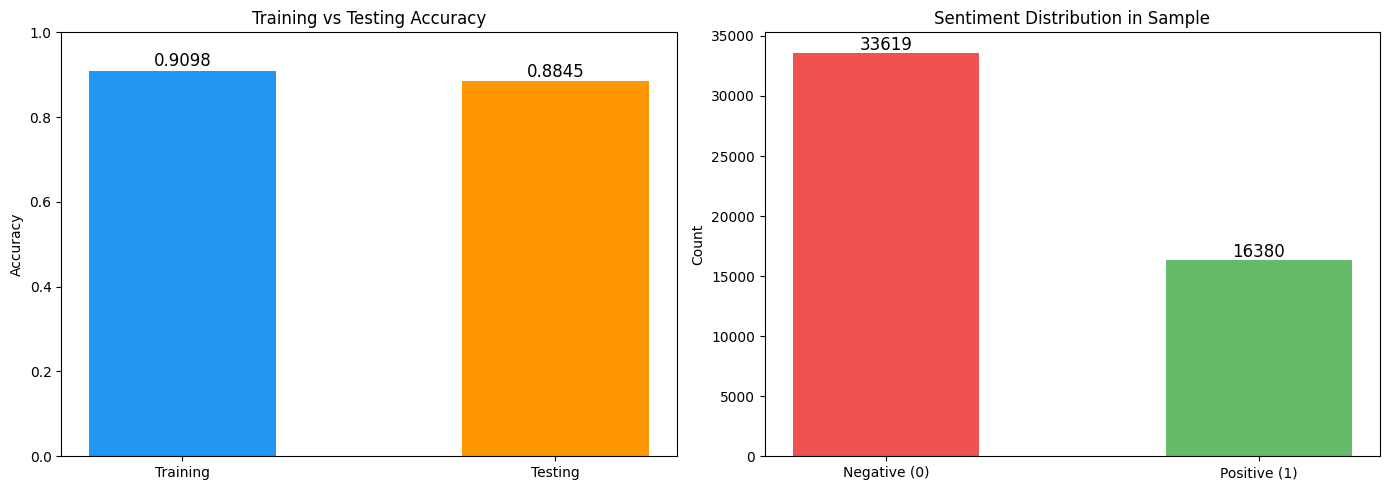

In [15]:
# --- Plot 1: Training vs Testing Accuracy Bar Chart ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart for train vs test accuracy
bars = axes[0].bar(['Training', 'Testing'], [train_accuracy, test_accuracy], color=['#2196F3', '#FF9800'], width=0.5)
axes[0].set_ylim(0, 1.0)
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Training vs Testing Accuracy')
for bar in bars:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height + 0.01, f'{height:.4f}', ha='center', fontsize=12)

# --- Plot 2: Sentiment Distribution in Dataset ---
sentiment_counts = df_sample['Sentiment'].value_counts()
axes[1].bar(['Negative (0)', 'Positive (1)'], sentiment_counts.values, color=['#EF5350', '#66BB6A'], width=0.5)
axes[1].set_ylabel('Count')
axes[1].set_title('Sentiment Distribution in Sample')
for i, v in enumerate(sentiment_counts.values):
    axes[1].text(i, v + 200, str(v), ha='center', fontsize=12)

plt.tight_layout()
plt.show()

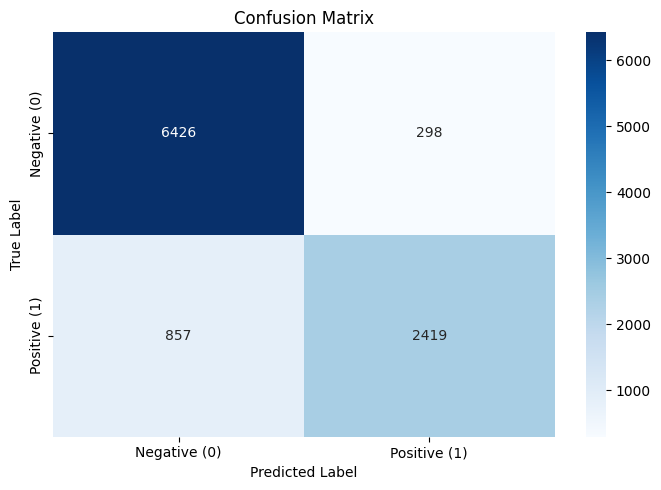

In [16]:
# --- Plot 3: Confusion Matrix Heatmap ---
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative (0)', 'Positive (1)'],
            yticklabels=['Negative (0)', 'Positive (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

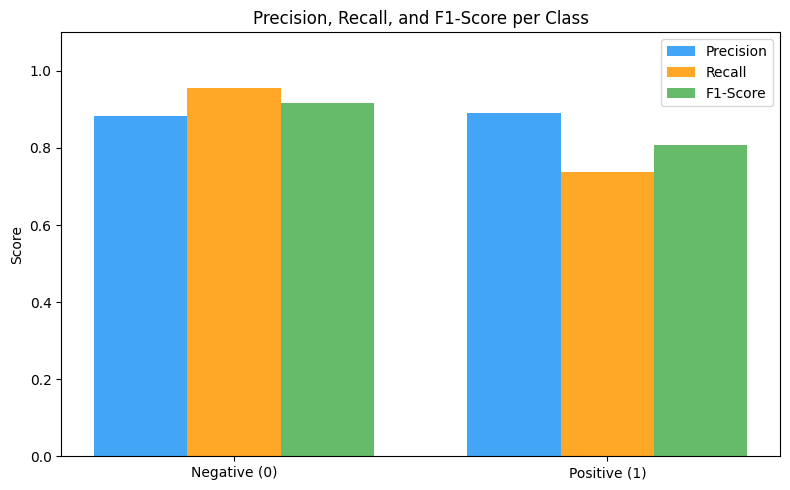

In [17]:
# --- Plot 4: Precision, Recall, F1-Score per Class ---
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_test, y_pred, average=None)
recall = recall_score(y_test, y_pred, average=None)
f1 = f1_score(y_test, y_pred, average=None)

x_labels = ['Negative (0)', 'Positive (1)']
x = range(len(x_labels))
width = 0.25

plt.figure(figsize=(8, 5))
plt.bar([i - width for i in x], precision, width, label='Precision', color='#42A5F5')
plt.bar(x, recall, width, label='Recall', color='#FFA726')
plt.bar([i + width for i in x], f1, width, label='F1-Score', color='#66BB6A')

plt.xticks(x, x_labels)
plt.ylim(0, 1.1)
plt.ylabel('Score')
plt.title('Precision, Recall, and F1-Score per Class')
plt.legend()
plt.tight_layout()
plt.show()